# Enable Inline Display in Jupyter
For displaying plots inline in the notebook, enable inline plotting

In [1]:
%matplotlib inline

# Preliminary settings
Libraries imported.

TensorFlow and other relevant libraries for building the image captioning model.

In [2]:
import tensorflow as tf

# You'll generate plots of attention in order to see which parts of an image
# our model focuses on during captioning
import matplotlib.pyplot as plt

# Scikit-learn includes many helpful utilities
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

import collections
import random
import re
import numpy as np
import os
import time
import json
from glob import glob
from PIL import Image
import pickle
from typing import List, Dict
import math

In [3]:
# Bengali font setup
def setup_bengali_fonts():
    import matplotlib.font_manager as fm
    """Setup Bengali fonts for matplotlib with fallback options"""
    
    # List of Bengali fonts to try (in order of preference)
    bengali_fonts = [
        'Kalpurush',           # Popular Bengali font
        'SolaimanLipi',        # Another common Bengali font
        'Noto Sans Bengali',   # Google's Noto font
        'Mukti',               # Open source Bengali font
        'Vrinda',              # Windows Bengali font
        'Lohit Bengali',       # Linux Bengali font
        'FreeSerif',           # Fallback with Unicode support
        'DejaVu Sans'          # Final fallback
    ]
    
    # Find available fonts on the system
    available_fonts = [f.name for f in fm.fontManager.ttflist]
    print("Available fonts containing 'Bengali' or 'Bangla':")
    bengali_available = [f for f in available_fonts if 'bengali' in f.lower() or 'bangla' in f.lower()]
    for font in bengali_available:
        print(f"  - {font}")
    
    # Try to find a working Bengali font
    working_font = None
    for font in bengali_fonts:
        if font in available_fonts:
            working_font = font
            print(f"Using Bengali font: {font}")
            break
    
    if working_font:
        plt.rcParams['font.family'] = [working_font]
    else:
        print("No specific Bengali font found, using system default with Unicode support")
        plt.rcParams['font.family'] = ['DejaVu Sans', 'Arial Unicode MS', 'sans-serif']
    
    # Additional font settings for better Bengali rendering
    plt.rcParams['font.size'] = 12
    plt.rcParams['axes.unicode_minus'] = False  # Fix minus sign display
    
    print("Current font family:", plt.rcParams['font.family'])
    return working_font

In [4]:
# Test Bengali text rendering
def test_bengali_rendering():
    """Test if Bengali text renders properly"""
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Test Bengali text
    bengali_text = "বাংলা ভাষা"  # "Bengali language" in Bengali
    english_text = "Bengali Language"
    
    ax.text(0.5, 0.7, bengali_text, fontsize=16, ha='center', transform=ax.transAxes)
    ax.text(0.5, 0.5, english_text, fontsize=14, ha='center', transform=ax.transAxes)
    ax.text(0.5, 0.3, f"Font: {plt.rcParams['font.family'][0]}", 
            fontsize=12, ha='center', transform=ax.transAxes)
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title("Bengali Font Rendering Test")
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return fig

Available fonts containing 'Bengali' or 'Bangla':
  - Noto Sans Bengali
  - Noto Sans Bengali
Using Bengali font: Noto Sans Bengali
Current font family: ['Noto Sans Bengali']

Testing Bengali font rendering...


/tmp/ipykernel_1581/2322115363.py:20: UserWarning: Glyph 108 (l) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1581/2322115363.py:20: UserWarning: Glyph 112 (p) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1581/2322115363.py:20: UserWarning: Glyph 66 (B) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1581/2322115363.py:20: UserWarning: Glyph 101 (e) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1581/2322115363.py:20: UserWarning: Glyph 110 (n) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1581/2322115363.py:20: UserWarning: Glyph 103 (g) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1581/2322115363.py:20: UserWarning: Glyph 97 (a) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1581/2322115363.py:20: UserWarning: Glyph 105 (i) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1581/2322115363.py:20: UserWarning: Glyph 70 (F) missing from current font.
  plt.t

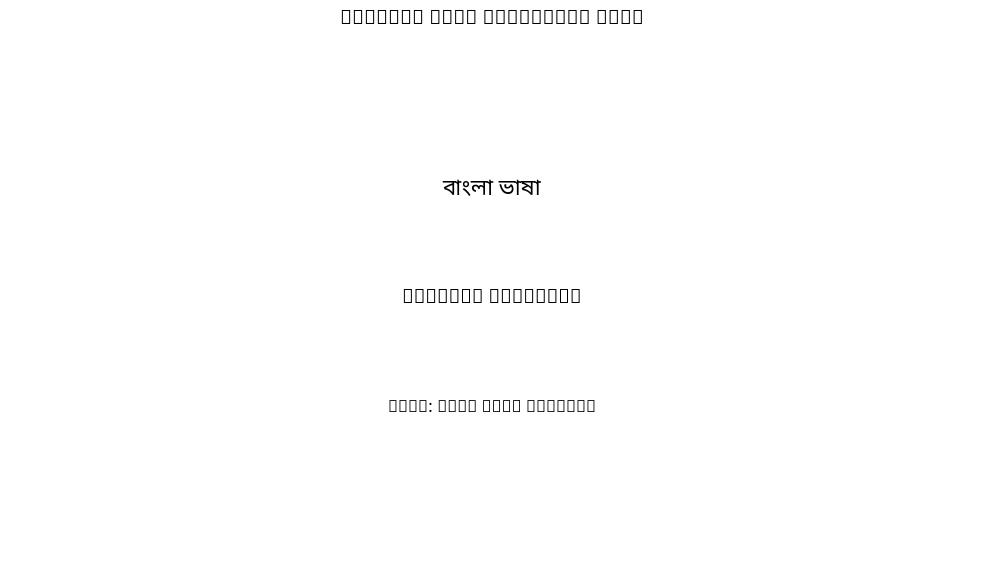

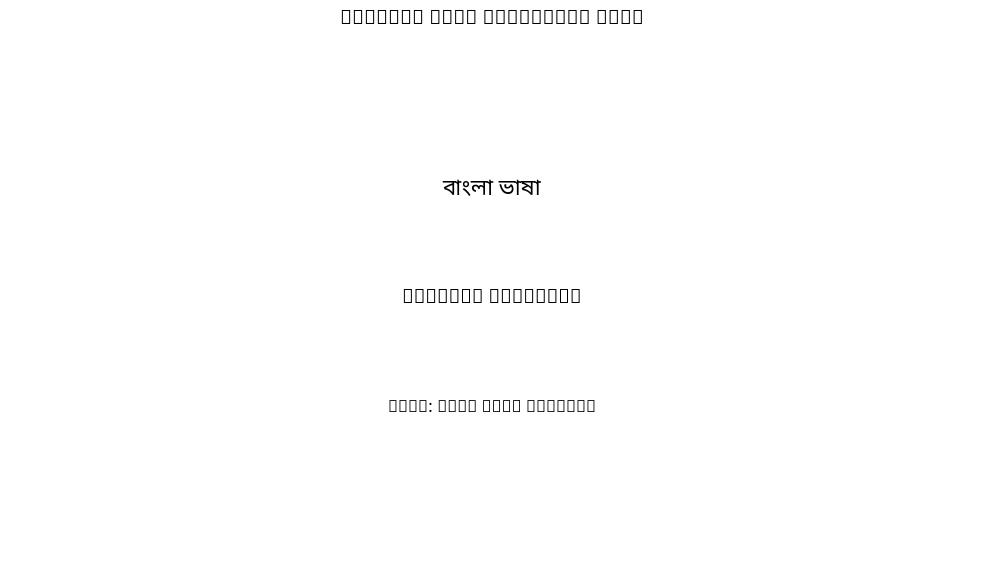

In [5]:
# Robust font setup
working_font = setup_bengali_fonts()

# Test the font rendering
print("\nTesting Bengali font rendering...")
# Test rendering
test_bengali_rendering()

In [6]:
# --- GPU Configuration ---
# Set ENABLE_GPU_LIMITS to False when training on a capable machine
ENABLE_GPU_LIMITS = True      # True = limit VRAM, False = allow full VRAM but enable growth
GPU_MEMORY_LIMIT_MB = None    # Set an int (MB) to fix the limit, or None for auto 80% capacity
MIN_SAFE_VRAM_MB = 1024       # Warn if limit is set below this (1GB default)

In [7]:
# Check if GPUs are available
gpus = tf.config.experimental.list_physical_devices('GPU')

if gpus:
    try:
        for gpu in gpus:
            details = tf.config.experimental.get_device_details(gpu)
            gpu_name = details.get("device_name", "Unknown GPU")
            total_mem_bytes = details.get("memory_limit", None)

            if total_mem_bytes:
                total_mem_mb = round(total_mem_bytes / (1024**2), 2)
                print(f"🖥 Detected GPU: {gpu_name} | Total VRAM: {total_mem_mb} MB")

                if ENABLE_GPU_LIMITS and GPU_MEMORY_LIMIT_MB is None:
                    GPU_MEMORY_LIMIT_MB = int(total_mem_mb * 0.8)
                    print(f"🔄 VRAM limit auto-set to 80%: {GPU_MEMORY_LIMIT_MB} MB")

                if ENABLE_GPU_LIMITS and GPU_MEMORY_LIMIT_MB > total_mem_mb:
                    print(f"⚠️ Requested limit ({GPU_MEMORY_LIMIT_MB} MB) exceeds VRAM.")
                    GPU_MEMORY_LIMIT_MB = int(total_mem_mb)

            else:
                print(f"🖥 Detected GPU: {gpu_name} | VRAM: Unknown")
                print(f"🔄 Will attempt to apply configured limit: {GPU_MEMORY_LIMIT_MB} MB")
                # Don't disable limits just because VRAM is unknown!

            # Check if limit is very low
            if ENABLE_GPU_LIMITS and GPU_MEMORY_LIMIT_MB and GPU_MEMORY_LIMIT_MB < MIN_SAFE_VRAM_MB:
                print(f"⚠️ VRAM limit {GPU_MEMORY_LIMIT_MB} MB is very low "
                      f"(below {MIN_SAFE_VRAM_MB} MB). Training may fail.")

            # Always enable memory growth
            if not tf.config.experimental.get_memory_growth(gpu):
                tf.config.experimental.set_memory_growth(gpu, True)

            # Apply VRAM limit if enabled and configured
            if ENABLE_GPU_LIMITS and GPU_MEMORY_LIMIT_MB is not None:
                if not tf.config.experimental.get_virtual_device_configuration(gpu):
                    tf.config.experimental.set_virtual_device_configuration(
                        gpu,
                        [tf.config.experimental.VirtualDeviceConfiguration(memory_limit=GPU_MEMORY_LIMIT_MB)]
                    )
                print(f"✅ GPU memory growth enabled with VRAM limit: {GPU_MEMORY_LIMIT_MB} MB.")
            else:
                print("⚡ GPU memory growth enabled with full VRAM (no limit).")

    except RuntimeError as e:
        print(f"⚠️ Warning: {e} - Skipping GPU reconfiguration.")
else:
    print("❌ No GPUs found.")

🖥 Detected GPU: NVIDIA GeForce MX350 | VRAM: Unknown
🔄 Will attempt to apply configured limit: None MB
⚡ GPU memory growth enabled with full VRAM (no limit).


2026-05-27 12:25:08.244034: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:922] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-27 12:25:08.320880: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:922] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-27 12:25:08.321217: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:922] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-27 12:25:08.322312: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:922] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been built without NUMA support.


In [8]:
# --- Configuration ---
ANNOTATION_FILE = '/data/rxxch9vw59-2/captions.json'
IMAGE_DIR = '/data/rxxch9vw59-2/images'
# Can be int, None, -1, or "inf"
TRAIN_LIMIT = "inf"                             # Number of images to use in training (before caption expansion)

In [9]:
from caption_parsers import JSONCaptionParser

# --- Parse Captions ---
parser = JSONCaptionParser()
caption_mapping: Dict[str, List[str]] = parser.extract(
    file_path=ANNOTATION_FILE,
    images_path=IMAGE_DIR,
    validate_images=True  # Ensure only valid image files are included
)


➡️  Parsing JSON: captions.json...
  → Finished parsing captions.json. Total valid entries: 1442.


In [10]:
# --- Shuffle and Prepare Dataset ---
image_paths = list(caption_mapping.keys())
random.shuffle(image_paths)

# Handle different TRAIN_LIMIT formats
if isinstance(TRAIN_LIMIT, str) and TRAIN_LIMIT.strip().lower() == "inf":
    train_image_paths = image_paths
elif TRAIN_LIMIT is None or TRAIN_LIMIT == -1:
    train_image_paths = image_paths
elif isinstance(TRAIN_LIMIT, (int, float)) and TRAIN_LIMIT > 0:
    train_image_paths = image_paths[:int(TRAIN_LIMIT)]
else:
    raise ValueError(f"Invalid TRAIN_LIMIT value: {TRAIN_LIMIT}")

print(f"✅ Using {len(train_image_paths)} image paths for training")

✅ Using 1442 image paths for training


In [11]:
# Build flat caption list and matching image list
train_captions: List[str] = []
img_name_vector: List[str] = []

for image_path in train_image_paths:
    captions = caption_mapping[image_path]
    train_captions.extend([f"<start> {cap} <end>" for cap in captions])
    img_name_vector.extend([image_path] * len(captions))

✅ Total training image paths selected: 1442
📌 First caption: <start> <start>একটা লোক রঙ মাখা শার্ট ও মাথায় কালারিং চুল লাগিয়ে পিছন ফিরে আছে।  <end>


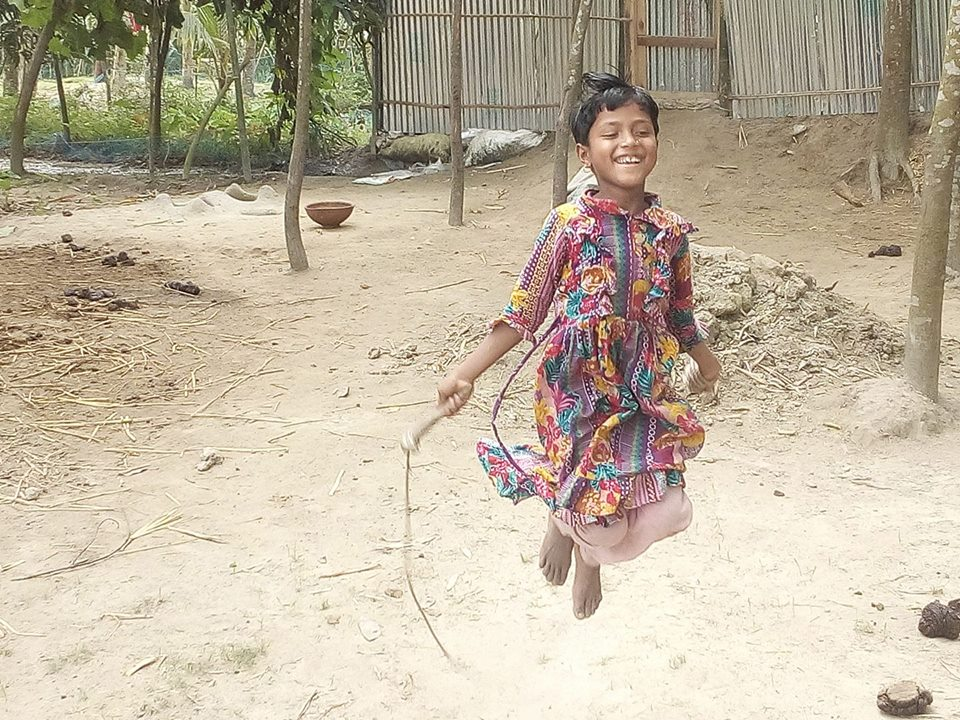

In [12]:
# --- Sample Output ---
print(f"✅ Total training image paths selected: {len(train_image_paths)}")
print(f"📌 First caption: {train_captions[0]}")
Image.open(img_name_vector[0]).show()

Preprocess the images using InceptionV3
Next, you will use InceptionV3 (which is pretrained on Imagenet) to classify each image. You will extract features from the last convolutional layer.

First, you will convert the images into InceptionV3's expected format by:

Resizing the image to 299px by 299px
Preprocess the images using the preprocess_input method to normalize the image so that it contains pixels in the range of -1 to 1, which matches the format of the images used to train InceptionV3.

In [13]:
import tensorflow as tf
import numpy as np
import cv2

IMG_SIZE = (299, 299)

def load_image_cv(path):
    path = path.numpy().decode() if isinstance(path, tf.Tensor) else path
    img = cv2.imread(path)
    if img is None:
        raise ValueError(f"Failed to load image: {path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    img = tf.keras.applications.inception_v3.preprocess_input(img.astype(np.float32))
    return img, path

def safe_load_image(path):
    try:
        return load_image_cv(path)
    except Exception as e:
        msg = f"⚠️ Skipping unreadable image: {path.numpy().decode()}"
        print(msg)
        with open("/results/skipped_images.log", "a", encoding="utf-8") as log_file:
            log_file.write(msg + "\n")
        return np.zeros((*IMG_SIZE, 3), dtype=np.float32), path.numpy().decode()

def tf_safe_load_image(path):
    image, path_str = tf.py_function(safe_load_image, [path], [tf.float32, tf.string])
    image.set_shape([*IMG_SIZE, 3])
    path_str.set_shape([])
    return image, path_str


Initialize InceptionV3 and load the pretrained Imagenet weights
Now you'll create a tf.keras model where the output layer is the last convolutional layer in the InceptionV3 architecture. The shape of the output of this layer is 8x8x2048. You use the last convolutional layer because you are using attention in this example. You don't perform this initialization during training because it could become a bottleneck.

You forward each image through the network and store the resulting vector in a dictionary (image_name --> feature_vector).
After all the images are passed through the network, you pickle the dictionary and save it to disk.

In [14]:
image_model = tf.keras.applications.InceptionV3(include_top=False,
                                                weights='imagenet')

new_input = image_model.input
hidden_layer = image_model.layers[-1].output

image_features_extract_model = tf.keras.Model(new_input, hidden_layer)

2026-05-27 12:25:10.625562: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-27 12:25:10.627284: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:922] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-27 12:25:10.627721: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:922] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-27 12:25:10.628102: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:922] could not open file to read NUMA node: /sys/bus/pci/devices/0000:02:00.0/numa_node
Your kernel may have been bui

Caching the features extracted from InceptionV3
You will pre-process each image with InceptionV3 and cache the output to disk. Caching the output in RAM would be faster but also memory intensive, requiring 8 * 8 * 2048 floats per image. At the time of writing, this exceeds the memory limitations of Colab (currently 12GB of memory).

Performance could be improved with a more sophisticated caching strategy (for example, by sharding the images to reduce random access disk I/O), but that would require more code.

The caching will take about 10 minutes to run in Colab with a GPU. If you'd like to see a progress bar, you can:

install tqdm:

!pip install tqdm

Import tqdm:

from tqdm import tqdm

Change the following line:

for img, path in image_dataset:

to:

for img, path in tqdm(image_dataset):

In [15]:
from tqdm import tqdm
import os

# Get unique images and filter out those that already have features
encode_train = sorted(set(img_name_vector))
encode_train_filtered = [
    img_path for img_path in encode_train 
    if not os.path.exists(f"{img_path}.npy")
]

print(f"📊 Total images: {len(encode_train)}")
print(f"🔍 Images needing processing: {len(encode_train_filtered)}")

if not encode_train_filtered:
    print("✅ All features already cached!")
else:
    # Only process images that need feature extraction
    image_dataset = tf.data.Dataset.from_tensor_slices(encode_train_filtered)
    image_dataset = image_dataset.map(
        tf_safe_load_image, num_parallel_calls=tf.data.experimental.AUTOTUNE
    ).batch(64)
    
    print("🔍 Extracting features for remaining images...")
    for img, path in tqdm(image_dataset):
        batch_features = image_features_extract_model(img)
        batch_features = tf.reshape(batch_features, (batch_features.shape[0], -1, batch_features.shape[3]))
        
        for bf, p in zip(batch_features, path):
            path_of_feature = p.numpy().decode("utf-8")
            npy_path = f"{path_of_feature}.npy"
            np.save(npy_path, bf.numpy())

📊 Total images: 1442
🔍 Images needing processing: 0
✅ All features already cached!


Preprocess and tokenize the captions
First, you'll tokenize the captions (for example, by splitting on spaces). This gives us a vocabulary of all of the unique words in the data (for example, "surfing", "football", and so on).
Next, you'll limit the vocabulary size to the top 5,000 words (to save memory). You'll replace all other words with the token "UNK" (unknown).
You then create word-to-index and index-to-word mappings.
Finally, you pad all sequences to be the same length as the longest one.

In [16]:
# Find the maximum length of any caption in our dataset
def calc_max_length(tensor):
    return max(len(t) for t in tensor)

In [17]:
# Choose the top 5000 words from the vocabulary
top_k = 10000 # can adjust to 5000 if needed
tokenizer = tf.keras.preprocessing.text.Tokenizer(
    num_words=top_k,
    oov_token="<unk>",  # will replace unknown words
    filters='!"#$%&()*+.,-/:;=?@[\]^_`{|}~ '  # removes unwanted characters
)
tokenizer.fit_on_texts(train_captions)
train_seqs = tokenizer.texts_to_sequences(train_captions)

In [18]:
tokenizer.word_index['<pad>'] = 0
tokenizer.index_word[0] = '<pad>'

In [19]:
# Create the tokenized vectors
train_seqs = tokenizer.texts_to_sequences(train_captions)

In [20]:
# Pad each vector to the max_length of the captions
# If you do not provide a max_length value, pad_sequences calculates it automatically
cap_vector = tf.keras.preprocessing.sequence.pad_sequences(train_seqs, padding='post')

In [21]:
print("✅ '<start>' token index:", tokenizer.word_index.get('<start>', '❌ Not found'))
print("✅ '<end>' token index:", tokenizer.word_index.get('<end>', '❌ Not found'))
print("✅ '<unk>' token index:", tokenizer.word_index.get('<unk>', '❌ Not found'))
print("✅ '<pad>' token index:", tokenizer.word_index.get('<pad>', '❌ Not found'))

✅ '<start>' token index: 2
✅ '<end>' token index: 3
✅ '<unk>' token index: 1
✅ '<pad>' token index: 0


In [22]:
# Calculates the max_length, which is used to store the attention weights
max_length = calc_max_length(train_seqs)

In [23]:
img_to_cap_vector = collections.defaultdict(list)
for img, cap in zip(img_name_vector, cap_vector):
  img_to_cap_vector[img].append(cap)

# Create training and validation sets using an 80-20 split randomly.
img_keys = list(img_to_cap_vector.keys())
random.shuffle(img_keys)

slice_index = int(len(img_keys)*0.8)
img_name_train_keys, img_name_val_keys = img_keys[:slice_index], img_keys[slice_index:]

img_name_train = []
cap_train = []
for imgt in img_name_train_keys:
  capt_len = len(img_to_cap_vector[imgt])
  img_name_train.extend([imgt] * capt_len)
  cap_train.extend(img_to_cap_vector[imgt])

img_name_val = []
cap_val = []
for imgv in img_name_val_keys:
  capv_len = len(img_to_cap_vector[imgv])
  img_name_val.extend([imgv] * capv_len)
  cap_val.extend(img_to_cap_vector[imgv])

In [24]:
len(img_name_train), len(cap_train), len(img_name_val), len(cap_val)

(2306, 2306, 578, 578)

Create a tf.data dataset for training
Our images and captions are ready! Next, let's create a tf.data dataset to use for training our model.

In [25]:
import tensorflow as tf
import numpy as np
import os

# Configuration
BATCH_SIZE = 64
BUFFER_SIZE = 1000
embedding_dim = 256
units = 512
vocab_size = top_k + 1
num_steps = len(img_name_train) // BATCH_SIZE
# Shape of the vector extracted from InceptionV3 is (64, 2048)
# These two variables represent that vector shape
features_shape = 2048
attention_features_shape = 64

In [26]:
# -------- SAFE LOADING FUNC -------- #
# Safe loader
def safe_map_func(img_name, cap):
    try:
        img_path = img_name.decode('utf-8') + '.npy'
        if not os.path.exists(img_path):
            raise FileNotFoundError(f"❌ File not found: {img_path}")
        img_tensor = np.load(img_path).astype(np.float32)
        return img_tensor, cap
    except Exception as e:
        print(f"⚠️ Skipping sample due to error: {e}")
        dummy_tensor = np.zeros((attention_features_shape, features_shape), dtype=np.float32)
        # Return dummy caption of same shape as real ones but filled with -1
        return dummy_tensor, np.full_like(cap, fill_value=-1)

In [27]:
def tf_safe_map_func(img_name, cap):
    img_tensor, cap = tf.numpy_function(
        safe_map_func, [img_name, cap], [tf.float32, tf.int32]
    )
    img_tensor.set_shape([attention_features_shape, features_shape])
    cap.set_shape([max_length])
    return img_tensor, cap

# -------- DATASET PIPELINE -------- #
# Dataset pipeline

# Create dataset from filenames and caption indices
dataset = tf.data.Dataset.from_tensor_slices((img_name_train, cap_train))

# Apply mapping safely
dataset = dataset.map(tf_safe_map_func, num_parallel_calls=tf.data.AUTOTUNE)

# Filter out samples where all caption tokens are -1
dataset = dataset.filter(lambda img, cap: tf.reduce_any(tf.not_equal(cap, -1)))

# Shuffle, batch and prefetch
dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE)
dataset = dataset.prefetch(tf.data.AUTOTUNE)


In [28]:
# -------- VALIDATION DATASET PIPELINE -------- #
val_dataset = tf.data.Dataset.from_tensor_slices((img_name_val, cap_val))

# Apply safe map
val_dataset = val_dataset.map(tf_safe_map_func, num_parallel_calls=tf.data.AUTOTUNE)

# Filter out samples where all caption tokens are -1
val_dataset = val_dataset.filter(lambda img, cap: tf.reduce_any(tf.not_equal(cap, -1)))

# Batch and prefetch (no shuffle for validation)
val_dataset = val_dataset.batch(BATCH_SIZE)
val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)

val_steps = len(img_name_val) // BATCH_SIZE

Model:

Fun fact: the decoder below is identical to the one in the example for Neural Machine Translation with Attention.

The model architecture is inspired by the Show, Attend and Tell paper.

In this example, you extract the features from the lower convolutional layer of InceptionV3 giving us a vector of shape (8, 8, 2048).
You squash that to a shape of (64, 2048).
This vector is then passed through the CNN Encoder (which consists of a single Fully connected layer).
The RNN (here GRU) attends over the image to predict the next word.

In [29]:
class BahdanauAttention(tf.keras.Model):
  def __init__(self, units):
    super(BahdanauAttention, self).__init__()
    self.W1 = tf.keras.layers.Dense(units)
    self.W2 = tf.keras.layers.Dense(units)
    self.V = tf.keras.layers.Dense(1)

  def call(self, features, hidden):
    # features(CNN_encoder output) shape == (batch_size, 64, embedding_dim)

    # hidden shape == (batch_size, hidden_size)
    # hidden_with_time_axis shape == (batch_size, 1, hidden_size)
    hidden_with_time_axis = tf.expand_dims(hidden, 1)

    # attention_hidden_layer shape == (batch_size, 64, units)
    attention_hidden_layer = (tf.nn.tanh(self.W1(features) +
                                         self.W2(hidden_with_time_axis)))

    # score shape == (batch_size, 64, 1)
    # This gives you an unnormalized score for each image feature.
    score = self.V(attention_hidden_layer)

    # attention_weights shape == (batch_size, 64, 1)
    attention_weights = tf.nn.softmax(score, axis=1)

    # context_vector shape after sum == (batch_size, hidden_size)
    context_vector = attention_weights * features
    context_vector = tf.reduce_sum(context_vector, axis=1)

    return context_vector, attention_weights

In [30]:
class CNN_Encoder(tf.keras.Model):
    # Since you have already extracted the features and dumped it using pickle
    # This encoder passes those features through a Fully connected layer
    def __init__(self, embedding_dim):
        super(CNN_Encoder, self).__init__()
        # shape after fc == (batch_size, 64, embedding_dim)
        self.fc = tf.keras.layers.Dense(embedding_dim)

    def call(self, x):
        x = self.fc(x)
        x = tf.nn.relu(x)
        return x

In [31]:
class RNN_Decoder(tf.keras.Model):
  def __init__(self, embedding_dim, units, vocab_size):
    super(RNN_Decoder, self).__init__()
    self.units = units

    self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
    self.gru = tf.keras.layers.GRU(self.units,
                                   return_sequences=True,
                                   return_state=True,
                                   recurrent_initializer='glorot_uniform')
    self.fc1 = tf.keras.layers.Dense(self.units)
    self.fc2 = tf.keras.layers.Dense(vocab_size)

    self.attention = BahdanauAttention(self.units)

  def call(self, x, features, hidden):
    # defining attention as a separate model
    context_vector, attention_weights = self.attention(features, hidden)

    # x shape after passing through embedding == (batch_size, 1, embedding_dim)
    x = self.embedding(x)

    # x shape after concatenation == (batch_size, 1, embedding_dim + hidden_size)
    x = tf.concat([tf.expand_dims(context_vector, 1), x], axis=-1)

    # passing the concatenated vector to the GRU
    with tf.device('/device:CPU:0'):
      output, state = self.gru(x)

    # shape == (batch_size, max_length, hidden_size)
    x = self.fc1(output)

    # x shape == (batch_size * max_length, hidden_size)
    x = tf.reshape(x, (-1, x.shape[2]))

    # output shape == (batch_size * max_length, vocab)
    x = self.fc2(x)

    return x, state, attention_weights

  def reset_state(self, batch_size):
    return tf.zeros((batch_size, self.units))

In [32]:
encoder = CNN_Encoder(embedding_dim)
decoder = RNN_Decoder(embedding_dim, units, vocab_size)

In [33]:
optimizer = tf.keras.optimizers.Adam()
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True, reduction='none')

def loss_function(real, pred):
  mask = tf.math.logical_not(tf.math.equal(real, 0))
  loss_ = loss_object(real, pred)

  mask = tf.cast(mask, dtype=loss_.dtype)
  loss_ *= mask

  return tf.reduce_mean(loss_)

In [34]:
# --- Paths ---
best_metadata_path = "/results/best_model_metadata.json"
train_ckpt_dir = "/results/train"

In [35]:
ckpt = tf.train.Checkpoint(encoder=encoder, decoder=decoder, optimizer = optimizer)
ckpt_manager = tf.train.CheckpointManager(ckpt, train_ckpt_dir, max_to_keep=5)

In [36]:
start_epoch = 0
if ckpt_manager.latest_checkpoint:
  start_epoch = int(ckpt_manager.latest_checkpoint.split('-')[-1])
  # restoring the latest checkpoint in checkpoint_path
  ckpt.restore(ckpt_manager.latest_checkpoint)

Training:

You extract the features stored in the respective .npy files and then pass those features through the encoder.
The encoder output, hidden state(initialized to 0) and the decoder input (which is the start token) is passed to the decoder.
The decoder returns the predictions and the decoder hidden state.
The decoder hidden state is then passed back into the model and the predictions are used to calculate the loss.
Use teacher forcing to decide the next input to the decoder.
Teacher forcing is the technique where the target word is passed as the next input to the decoder.
The final step is to calculate the gradients and apply it to the optimizer and backpropagate.

In [37]:
from tqdm import tqdm
import numpy as np

# --- Early Stopping Parameters ---
patience = 5  # Stop after 5 epochs without improvement
best_loss = np.inf
wait = 0
best_epoch = 0
best_ckpt_path = "/results/best_model"
EPOCHS = 100

In [38]:
# adding this in a separate cell because if you run the training cell
# many times, the arrays will be reset
loss_plot_train = []
loss_plot_val = []
training_history = []  # Stores tuples: (epoch, train_loss, val_loss)

In [39]:
@tf.function
def train_step(img_tensor, target):
    loss = 0
    hidden = decoder.reset_state(batch_size=target.shape[0])
    dec_input = tf.expand_dims([tokenizer.word_index['<start>']] * target.shape[0], 1)

    with tf.GradientTape() as tape:
        features = encoder(img_tensor)
        for i in range(1, target.shape[1]):
            predictions, hidden, _ = decoder(dec_input, features, hidden)
            loss += loss_function(target[:, i], predictions)
            dec_input = tf.expand_dims(target[:, i], 1)  # Teacher forcing

    total_loss = loss / int(target.shape[1])
    trainable_variables = encoder.trainable_variables + decoder.trainable_variables
    gradients = tape.gradient(loss, trainable_variables)
    optimizer.apply_gradients(zip(gradients, trainable_variables))

    return loss, total_loss

In [40]:
@tf.function
def val_step(img_tensor, target):
    loss = 0
    hidden = decoder.reset_state(batch_size=target.shape[0])
    dec_input = tf.expand_dims([tokenizer.word_index['<start>']] * target.shape[0], 1)

    features = encoder(img_tensor)
    for i in range(1, target.shape[1]):
        predictions, hidden, _ = decoder(dec_input, features, hidden)
        loss += loss_function(target[:, i], predictions)
        dec_input = tf.expand_dims(target[:, i], 1)

    total_loss = loss / int(target.shape[1])
    return loss, total_loss

In [41]:
# --- Save Tokenizer Always ---
# Path to save tokenizer
tokenizer_path = "/results/tokenizer.pkl"

# Save tokenizer to file
with open(tokenizer_path, 'wb') as tok_f:
    pickle.dump(tokenizer, tok_f)

In [42]:
metadata = {}

In [43]:
# ---------------------------
# ✅ Checkpoint Helpers
# ---------------------------
def best_model_exists(metadata_path):
    if not os.path.exists(metadata_path):
        return False
    try:
        with open(metadata_path, "r") as f:
            meta = json.load(f)
        ckpt_path = meta.get("best_model_ckpt")
        return ckpt_path and os.path.exists(ckpt_path + ".index")
    except Exception:
        return False

def training_ckpt_exists(ckpt_dir):
    ckpt_manager = tf.train.CheckpointManager(tf.train.Checkpoint(), ckpt_dir, max_to_keep=5)
    return bool(ckpt_manager.latest_checkpoint)

# ---------------------------
# 🔁 Training Loop Function
# ---------------------------
def run_training_loop(start_epoch, EPOCHS, dataset, val_dataset,
                      num_steps, val_steps, patience,
                      ckpt_manager, best_ckpt_path, best_metadata_path,
                      tokenizer_path):

    global best_loss, best_epoch, wait, saved_ckpt_path

    for epoch in range(start_epoch, EPOCHS):
        start = time.time()
        total_train_loss = 0.0
        total_val_loss = 0.0

        # --- Training loop ---
        pbar_train = tqdm(enumerate(dataset), total=num_steps,
                          desc=f"Epoch {epoch+1}/{EPOCHS} [Train]", unit="batch")
        for batch, (img_tensor, target) in pbar_train:
            batch_loss, t_loss = train_step(img_tensor, target)
            total_train_loss += t_loss
            pbar_train.set_postfix({"Batch Loss": f"{batch_loss.numpy() / int(target.shape[1]):.4f}"})

        epoch_train_loss = total_train_loss / num_steps
        loss_plot_train.append(epoch_train_loss)

        # --- Validation loop ---
        pbar_val = tqdm(enumerate(val_dataset), total=val_steps,
                        desc=f"Epoch {epoch+1}/{EPOCHS} [Val]", unit="batch")
        for batch, (img_tensor, target) in pbar_val:
            batch_loss, t_loss = val_step(img_tensor, target)
            total_val_loss += t_loss
            pbar_val.set_postfix({"Batch Loss": f"{batch_loss.numpy() / int(target.shape[1]):.4f}"})

        epoch_val_loss = total_val_loss / val_steps
        loss_plot_val.append(epoch_val_loss)

        # Save history
        training_history.append((epoch + 1, float(epoch_train_loss), float(epoch_val_loss)))

        # --- Save regular checkpoint every 5 epochs ---
        if epoch % 5 == 0:
            ckpt_manager.save()

        # --- Epoch summary ---
        print(f"\nEpoch {epoch + 1} Train Loss: {epoch_train_loss:.6f} | Val Loss: {epoch_val_loss:.6f}")
        print(f"Time taken: {time.time() - start:.2f} sec")

        # --- Early Stopping ---
        if epoch_val_loss < best_loss:
            best_loss = epoch_val_loss
            best_epoch = epoch
            wait = 0
            print(f"✅ Validation loss improved to {best_loss:.6f}, saving best model...")
            best_ckpt_manager = tf.train.CheckpointManager(ckpt, best_ckpt_path, max_to_keep=1)
            saved_ckpt_path = best_ckpt_manager.save()
        else:
            wait += 1
            print(f"No improvement for {wait} epoch(s).")
            if wait >= patience:
                print(f"⏹ Early stopping triggered at epoch {epoch+1}.")
                print(f"Best model saved at: {best_ckpt_path}")
                break

    # --- Save Best Model Metadata ---
    metadata = {
        "best_epoch": best_epoch + 1,
        "best_val_loss": float(best_loss),
        "best_model_dir": best_ckpt_path,
        "best_model_ckpt": saved_ckpt_path,
        "tokenizer_path": tokenizer_path
    }
    with open(best_metadata_path, 'w') as f:
        json.dump(metadata, f, indent=4)
    print(f"\n📄 Best model metadata saved to {best_metadata_path}")

In [44]:
# ---------------------------
# 🚀 Orchestrator
# ---------------------------
# Always save tokenizer
tokenizer_path = "/results/tokenizer.pkl"
with open(tokenizer_path, 'wb') as tok_f:
    pickle.dump(tokenizer, tok_f)

if best_model_exists(best_metadata_path):
    print("✅ Best model already exists — skipping training.")
    with open(best_metadata_path, "r") as f:
        metadata = json.load(f)
    saved_ckpt_path = metadata.get("best_model_ckpt")
    best_epoch = metadata.get("best_epoch", None)
    best_loss = metadata.get("best_val_loss", None)

elif training_ckpt_exists(train_ckpt_dir):
    print("🔄 Found training checkpoint — resuming training...")
    ckpt.restore(tf.train.latest_checkpoint(train_ckpt_dir))
    print(f"✅ Restored checkpoint: {tf.train.latest_checkpoint(train_ckpt_dir)}")
    run_training_loop(start_epoch, EPOCHS, dataset, val_dataset,
                      num_steps, val_steps, patience,
                      ckpt_manager, best_ckpt_path, best_metadata_path,
                      tokenizer_path)

else:
    print("🚀 Starting training from scratch...")
    run_training_loop(start_epoch, EPOCHS, dataset, val_dataset,
                      num_steps, val_steps, patience,
                      ckpt_manager, best_ckpt_path, best_metadata_path,
                      tokenizer_path)

✅ Best model already exists — skipping training.


In [45]:
if not best_model_exists(best_metadata_path):
    # ✅ Training happened, so history and plots exist
    import csv

    # --- Save Training History to CSV ---
    csv_path = "/results/training_history.csv"
    with open(csv_path, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(["Epoch", "Train Loss", "Validation Loss"])
        writer.writerows(training_history)
    print(f"📄 Training history saved to {csv_path}")

    # --- Loss Plot after Training ---
    early_stop_epoch = best_epoch + 1  # convert to 1-based for display

    fig = plt.figure(figsize=(6, 4))
    plt.plot(loss_plot_train, color='r', label='Training Loss')
    plt.plot(loss_plot_val, color='b', label='Validation Loss')

    # Mark early stop
    plt.axvline(
        x=early_stop_epoch - 1,
        color='g',
        linestyle='--',
        linewidth=1.5,
        label=f'Early Stop @ Epoch {early_stop_epoch}'
    )

    # Shade after early stop
    plt.axvspan(
        early_stop_epoch - 1,
        len(loss_plot_train) - 1,
        color='gray',
        alpha=0.2,
        label='Training stopped here'
    )

    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training & Validation Loss with Early Stopping')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()

    plt.savefig("/results/loss.png", dpi=300)
    plt.show()
else:
    print("📌 Skipped history saving & plotting (best model already exists).")


📌 Skipped history saving & plotting (best model already exists).


In [46]:
import json
import os
import tensorflow as tf

import pickle

def load_best_or_latest_checkpoint(encoder, decoder, optimizer,
                                   best_metadata_path="/results/best_model_metadata.json",
                                   train_ckpt_dir="/results/train"):
    """
    Attempts to load the best checkpoint from metadata.
    Falls back to the latest checkpoint in train_ckpt_dir if metadata is missing or corrupted.
    Also loads tokenizer if path is available in metadata.
    """
    ckpt = tf.train.Checkpoint(encoder=encoder, decoder=decoder, optimizer=optimizer)
    tokenizer = None
    
    if os.path.exists(best_metadata_path):
        try:
            with open(best_metadata_path, 'r') as f:
                meta = json.load(f)
            
            # Restore model checkpoint
            best_ckpt_path = meta.get("best_model_ckpt")
            if best_ckpt_path and os.path.exists(best_ckpt_path + ".index"):
                ckpt.restore(best_ckpt_path).expect_partial()
                print(f"✅ Restored best model from epoch {meta['best_epoch']} with val_loss={meta['best_val_loss']}")
            else:
                print("⚠️ Best checkpoint file not found, falling back to latest checkpoint...")
            
            # Load tokenizer if available
            tok_path = meta.get("tokenizer_path")
            if tok_path and os.path.exists(tok_path):
                with open(tok_path, 'rb') as tok_f:
                    tokenizer = pickle.load(tok_f)
                print(f"✅ Tokenizer loaded from {tok_path}")
            else:
                print("⚠️ No tokenizer found in metadata.")
                
            return ckpt, tokenizer

        except Exception as e:
            print(f"⚠️ Error reading metadata file: {e}. Falling back to latest checkpoint...")

    # Fallback: Load latest checkpoint from training dir
    ckpt_manager = tf.train.CheckpointManager(ckpt, train_ckpt_dir, max_to_keep=5)
    if ckpt_manager.latest_checkpoint:
        ckpt.restore(ckpt_manager.latest_checkpoint).expect_partial()
        print(f"✅ Restored latest checkpoint: {ckpt_manager.latest_checkpoint}")
    else:
        print("❌ No checkpoints found!")
    
    return ckpt, tokenizer



In [47]:
ckpt, tokenizer = load_best_or_latest_checkpoint(
    encoder=encoder,
    decoder=decoder,
    optimizer=optimizer
)

if tokenizer is None:
    raise RuntimeError("Tokenizer not found — cannot proceed with inference!")

✅ Restored best model from epoch 10 with val_loss=0.08
✅ Tokenizer loaded from /results/tokenizer.pkl


In [48]:
# ----------------------------
# 📁 Directory Configurations
# ----------------------------
output_dir = "/results/"
generated_images_dir = os.path.join(output_dir, "generated_images")
html_report_path = os.path.join(output_dir, "generated_captions_report.html")

os.makedirs(output_dir, exist_ok=True)
os.makedirs(generated_images_dir, exist_ok=True)

# Initialize storage
html_content = "<html><body><h1>Generated Captions</h1>"
captions = {}
bleu_scores = {}

# Config
display_count = 5   # Show only 5 inline
save_count = 20     # Save only first 20 attention plots
saved_image_count = 0

In [49]:
import math

# ----------------------------
# 🔹 BLEU Helpers
# ----------------------------
def n_gram_precision(refs, pred, n):
    pred_ngrams = [" ".join(pred[i:i+n]) for i in range(len(pred)-n+1)]
    ref_ngrams = set()
    for ref in refs:
        ref_ngrams.update([" ".join(ref[i:i+n]) for i in range(len(ref)-n+1)])
    match_count = sum(1 for gram in pred_ngrams if gram in ref_ngrams)
    return match_count / len(pred_ngrams) if pred_ngrams else 0

def brevity_penalty(refs, pred):
    pred_len = len(pred)
    ref_lens = [len(r) for r in refs]
    closest_len = min(ref_lens, key=lambda rl: (abs(rl - pred_len), rl))
    if pred_len > closest_len:
        return 1
    return math.exp(1 - closest_len/pred_len) if pred_len > 0 else 0

def compute_bleu(refs, pred, max_n=4):
    pred_tokens = pred.split()
    ref_tokens = [r.split() for r in refs]
    precisions = [n_gram_precision(ref_tokens, pred_tokens, n) for n in range(1, max_n+1)]
    log_precision_sum = sum(math.log(p) for p in precisions if p > 0)
    return brevity_penalty(ref_tokens, pred_tokens) * math.exp(log_precision_sum/max_n)

def compute_average_bleu(scores):
    if not scores: return 0.0
    return sum(scores.values()) / len(scores)

Caption!

The evaluate function is similar to the training loop, except you don't use teacher forcing here. The input to the decoder at each time step is its previous predictions along with the hidden state and the encoder output.
Stop predicting when the model predicts the end token.
And store the attention weights for every time step.

In [50]:
# ----------------------------
# 🔹 Core Evaluate + Attention
# ----------------------------

# --- Core evaluation ---
def evaluate(image_path):
    """Generate caption + attention plot for a single image."""
    attention_plot = np.zeros((max_length, attention_features_shape))
    hidden = decoder.reset_state(batch_size=1)

    temp_input = tf.expand_dims(load_image_cv(image_path)[0], 0)
    img_tensor_val = image_features_extract_model(temp_input)
    img_tensor_val = tf.reshape(img_tensor_val, (img_tensor_val.shape[0], -1, img_tensor_val.shape[3]))
    features = encoder(img_tensor_val)

    dec_input = tf.expand_dims([tokenizer.word_index['<start>']], 0)
    result = []

    for i in range(max_length):
        predictions, hidden, attention_weights = decoder(dec_input, features, hidden)
        attention_plot[i] = tf.reshape(attention_weights, (-1,)).numpy()
        predicted_id = tf.random.categorical(predictions, 1)[0][0].numpy()
        word = tokenizer.index_word.get(predicted_id, '<unk>')
        result.append(word)

        if word == '<end>':
            return result, attention_plot

        dec_input = tf.expand_dims([predicted_id], 0)

    attention_plot = attention_plot[:len(result), :]
    return result, attention_plot

In [51]:
import matplotlib.cm as cm
import gc

def plot_attention(image_path, result, attention_plot, save_path=None, display_inline=False):
    temp_image = np.array(Image.open(image_path))
    cols = math.ceil(math.sqrt(len(result)))
    rows = math.ceil(len(result) / cols)

    fig = plt.figure(figsize=(15, 15))
    for l, word in enumerate(result):
        temp_att = np.resize(attention_plot[l], (8, 8))
        ax = fig.add_subplot(rows, cols, l + 1)
        ax.set_title(word)
        ax.axis("off")

        # Show original image
        ax.imshow(temp_image)

        # Overlay attention heatmap with jet colormap
        heatmap = cm.jet(temp_att)  # shape (8, 8, 4) with RGBA
        ax.imshow(heatmap, alpha=0.4, extent=(0, temp_image.shape[1], temp_image.shape[0], 0))

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    if display_inline:
        plt.show()
    plt.close(fig)
    gc.collect()

In [52]:
# Build dict of decoded ground-truth captions
val_captions_dict = {
    os.path.basename(img): " ".join([tokenizer.index_word[i] for i in cap if i not in [0]])
    for img, cap in zip(img_name_val, cap_val)
}

In [53]:
# ----------------------------
# 🔹 Generate Caption Wrapper
# ----------------------------

# --- Wrapper for flexible evaluation ---
def generate_caption(image_path, display_attention=True, save_attention=True, save_idx=None):
    global saved_image_count, html_content
    result, att = evaluate(image_path)
    pred_caption = " ".join(result)

    # Ground truth (if available)
    real_caption = None
    if image_path in img_name_val:
        gt_idx = img_name_val.index(image_path)
        real_caption = " ".join([tokenizer.index_word.get(i, '<unk>') for i in cap_val[gt_idx] if i not in [0]])

    print(f"\nImage: {image_path}")
    if real_caption: print(f"✅ GT: {real_caption}")
    print(f"🤖 Pred: {pred_caption}")

    # Save/display attention selectively
    if save_attention and saved_image_count < save_count:
        save_path = os.path.join(generated_images_dir, f"img_{save_idx or saved_image_count+1}.png")
        plot_attention(image_path, result, att,
                       save_path=save_path,
                       display_inline=(display_attention and saved_image_count < display_count))
        saved_image_count += 1

        # Add to HTML
        # Save relative path instead of absolute
        rel_path = os.path.relpath(save_path, output_dir)
        html_content += f"<div><h3>{os.path.basename(image_path)}</h3>"
        html_content += f"<p><b>GT:</b> {real_caption or 'N/A'}<br><b>Pred:</b> {pred_caption}</p>"
        html_content += f"<img src='{rel_path}' width='300'></div>"

    captions[os.path.basename(image_path)] = pred_caption
    return pred_caption


In [54]:
# ----------------- MODES -----------------

# ----------------------------
# 🔹 Modes
# ----------------------------
def run_random_single():
    """Pick a single random image from validation set."""
    image = random.choice(img_name_val)
    generate_caption(image, display_attention=True)

def run_random_batch(num_images=5):
    """Generate captions for N random images."""
    random_images = random.sample(img_name_val, num_images)
    for idx, image in enumerate(random_images, 1):
        generate_caption(image, display_attention=True, save_attention=True, save_idx=f"rand_{idx}")

def run_first_n(num_images=5):
    """Generate captions for first N validation images."""
    for idx, image in enumerate(img_name_val[:num_images], 1):
        generate_caption(image, display_attention=True, save_attention=True, save_idx=f"first_{idx}")

def run_all(save_output=False):
    """Generate captions for all validation images."""
    for idx, image in enumerate(img_name_val, 1):
        generate_caption(
            image,
            display_attention=False,  # skip live plotting to save time
            save_attention=save_output,
            save_idx=f"val_{idx}"
        )

def run_custom_images(image_paths, display_attention=True, save_attention=True):
    """Generate captions for custom image paths."""
    for idx, image_path in enumerate(image_paths, 1):
        generate_caption(
            image_path,
            display_attention=display_attention,
            save_attention=save_attention,
            save_idx=f"custom_{idx}"
        )

In [55]:
# ----------------------------
# 🔹 Finalize Report
# ----------------------------
import csv
import numpy as np

def finalize_report():
    global html_content

    # Compute BLEU if ground-truths exist
    for img in captions:
        if img in val_captions_dict:
            bleu_scores[img] = compute_bleu([val_captions_dict[img]], captions[img])

    # Compute average
    avg_bleu = compute_average_bleu(bleu_scores)

    # Save captions to JSON
    with open(os.path.join(output_dir, "captions.json"), "w", encoding="utf-8") as f:
        json.dump(captions, f, indent=4, ensure_ascii=False)

    # Save BLEU to CSV
    with open(os.path.join(output_dir, "bleu_scores.csv"), "w", newline="", encoding="utf-8") as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(["Image", "BLEU"])
        for img, score in bleu_scores.items():
            writer.writerow([img, f"{score:.4f}"])
        writer.writerow(["Average", f"{avg_bleu:.4f}"])

    # --- Extra BLEU statistics ---
    if bleu_scores:
        bleu_values = list(bleu_scores.values())
        min_bleu = np.min(bleu_values)
        max_bleu = np.max(bleu_values)
        median_bleu = np.median(bleu_values)
        std_bleu = np.std(bleu_values)
        count_bleu = len(bleu_values)

        # Add BLEU stats to HTML
        html_content += f"""
        <div style='margin-top:20px'>
            <h2>📊 BLEU Score Summary</h2>
            <ul>
                <li><strong>Count:</strong> {count_bleu}</li>
                <li><strong>Min BLEU:</strong> {min_bleu:.4f}</li>
                <li><strong>Max BLEU:</strong> {max_bleu:.4f}</li>
                <li><strong>Median BLEU:</strong> {median_bleu:.4f}</li>
                <li><strong>Standard Deviation:</strong> {std_bleu:.4f}</li>
                <li><strong>Mean BLEU:</strong> {avg_bleu:.4f}</li>
            </ul>
        </div>
        """
    else:
        html_content += "<p>No BLEU scores available.</p>"

    # Finalize HTML
    html_content += "</body></html>"
    with open(html_report_path, "w", encoding="utf-8") as f:
        f.write(html_content)

    # Also save stats to TXT
    summary_path = os.path.join(output_dir, "bleu_summary.txt")
    with open(summary_path, "w", encoding="utf-8") as f:
        if bleu_scores:
            f.write(f"Count: {count_bleu}\n")
            f.write(f"Min BLEU: {min_bleu:.4f}\n")
            f.write(f"Max BLEU: {max_bleu:.4f}\n")
            f.write(f"Median BLEU: {median_bleu:.4f}\n")
            f.write(f"Standard Deviation: {std_bleu:.4f}\n")
            f.write(f"Mean BLEU: {avg_bleu:.4f}\n")
        else:
            f.write("No BLEU scores available.\n")

    print(f"\n✅ Report saved: {html_report_path}")
    print(f"📊 BLEU summary saved: {summary_path}")


🚀 Starting Image Caption Inference Pipeline

📋 Available Inference Modes:
1. Single random validation image
2. Batch of random validation images
3. First N validation images

🎯 Mode 1: Single Random Image


2026-05-27 12:25:17.534505: I tensorflow/stream_executor/cuda/cuda_dnn.cc:368] Loaded cuDNN version 8401
2026-05-27 12:25:18.138128: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-05-27 12:25:18.139732: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-05-27 12:25:18.139790: W tensorflow/stream_executor/gpu/asm_compiler.cc:80] Couldn't get ptxas version string: INTERNAL: Couldn't invoke ptxas --version
2026-05-27 12:25:18.150178: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-05-27 12:25:18.150331: W tensorflow/stream_executor/gpu/redzone_allocator.cc:314] INTERNAL: Failed to launch ptxas
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This message will be only logged once.
2026-05-27 12:25:18.333742: W tensorflow/core/common_runtime/bf


Image: /data/rxxch9vw59-2/images/148.png
✅ GT: <start> <start>খালি শরীরে একজন পুরুষ মানুষ কাজ করছে। <end>
🤖 Pred: চরে <start>৪ দাঁড়িয়ে শরীরে তাকিয়ে খালের <end>


/tmp/ipykernel_1581/1717398526.py:23: UserWarning: Glyph 108 (l) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1581/1717398526.py:23: UserWarning: Glyph 112 (p) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1581/1717398526.py:23: UserWarning: Glyph 115 (s) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1581/1717398526.py:23: UserWarning: Glyph 116 (t) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1581/1717398526.py:23: UserWarning: Glyph 97 (a) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1581/1717398526.py:23: UserWarning: Glyph 114 (r) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1581/1717398526.py:23: UserWarning: Glyph 101 (e) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1581/1717398526.py:23: UserWarning: Glyph 110 (n) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1581/1717398526.py:23: UserWarning: Glyph 100 (d) missing from current font.
  plt

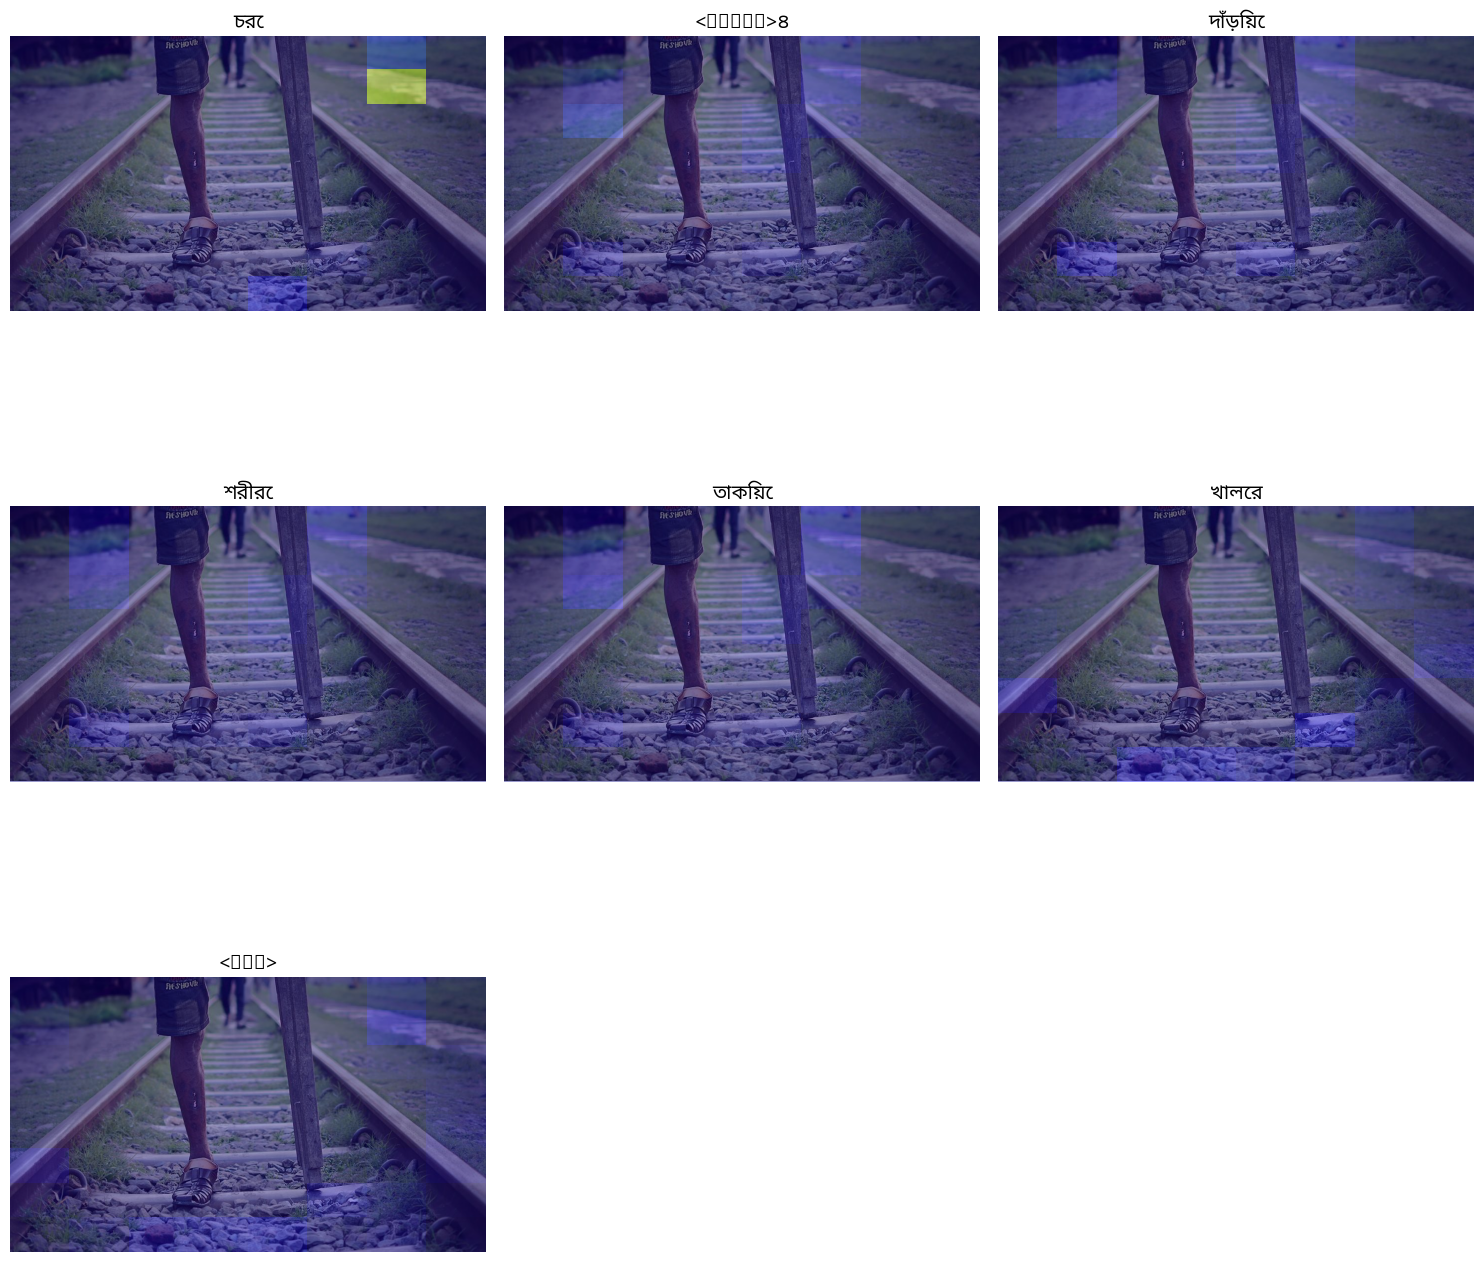


🎯 Mode 2: Random Batch (5 images)

Image: /data/rxxch9vw59-2/images/1589.png
✅ GT: <start> <start>একজন নারী একটি শিশু কোলে নিয়ে আছে। <end>
🤖 Pred: সাথে যাচ্ছে। সরিষা <unk> <start>শাড়ি মাথায় <end>


/tmp/ipykernel_1581/1717398526.py:23: UserWarning: Glyph 117 (u) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1581/1717398526.py:23: UserWarning: Glyph 107 (k) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1581/1717398526.py:25: UserWarning: Glyph 117 (u) missing from current font.
  plt.savefig(save_path, bbox_inches="tight")
/tmp/ipykernel_1581/1717398526.py:25: UserWarning: Glyph 107 (k) missing from current font.
  plt.savefig(save_path, bbox_inches="tight")
/opt/conda/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 107 (k) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


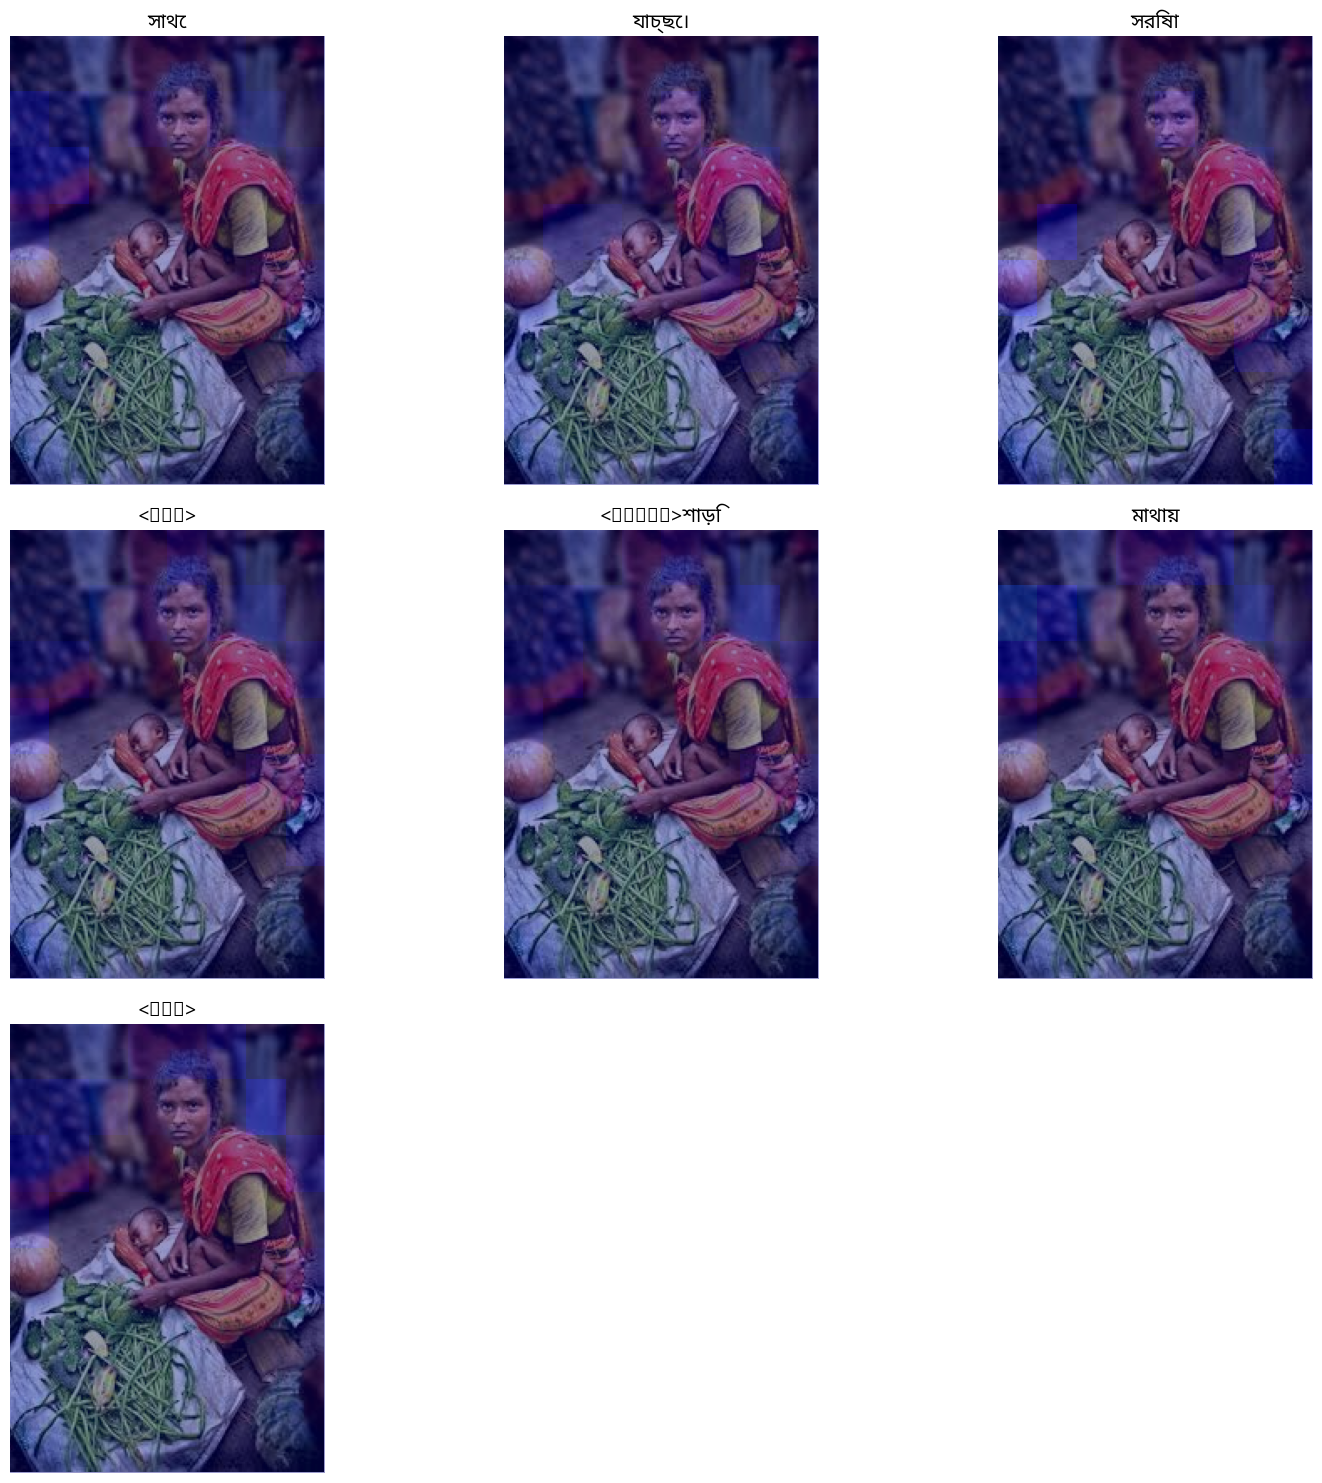


Image: /data/rxxch9vw59-2/images/1491.png
✅ GT: <start> <start>তিনজন বালিকা বসে আছে। <end>
🤖 Pred: শারীরিক <start>জলাশয়ের যাচ্ছে। একজন <end>


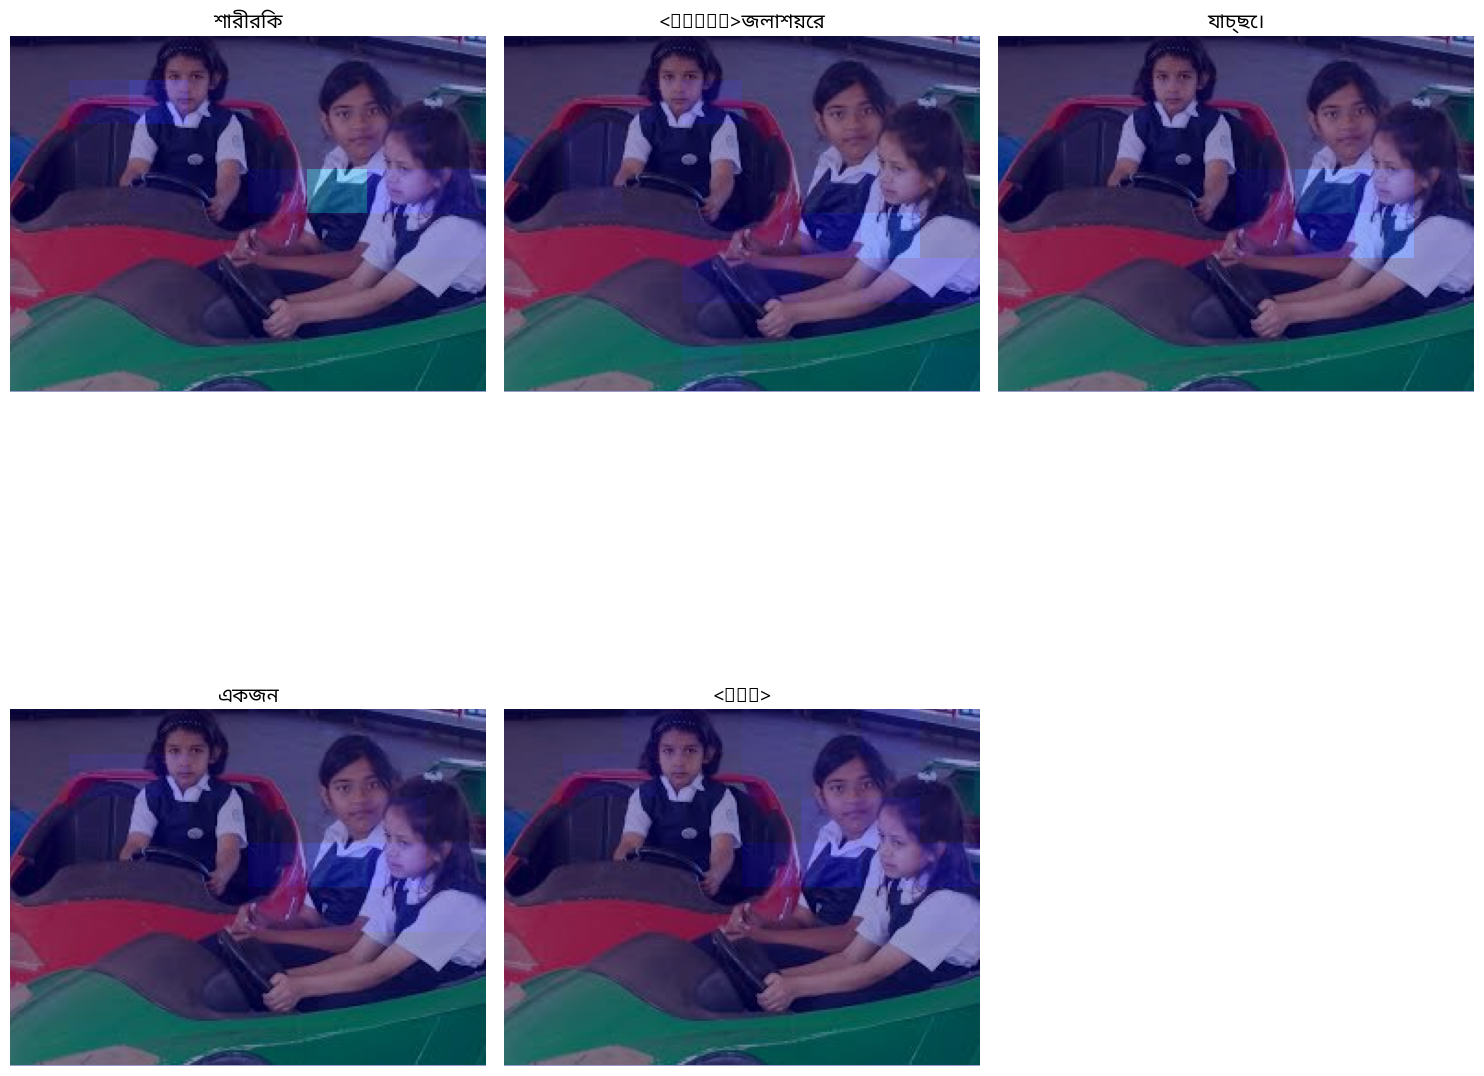


Image: /data/rxxch9vw59-2/images/1152.png
✅ GT: <start> <start>কয়েকজন শিশু মাথায় টুপি পরে পড়াশোনা করছে। <end>
🤖 Pred: শিশু ধরে <start>শাড়ি মাথায় <end>


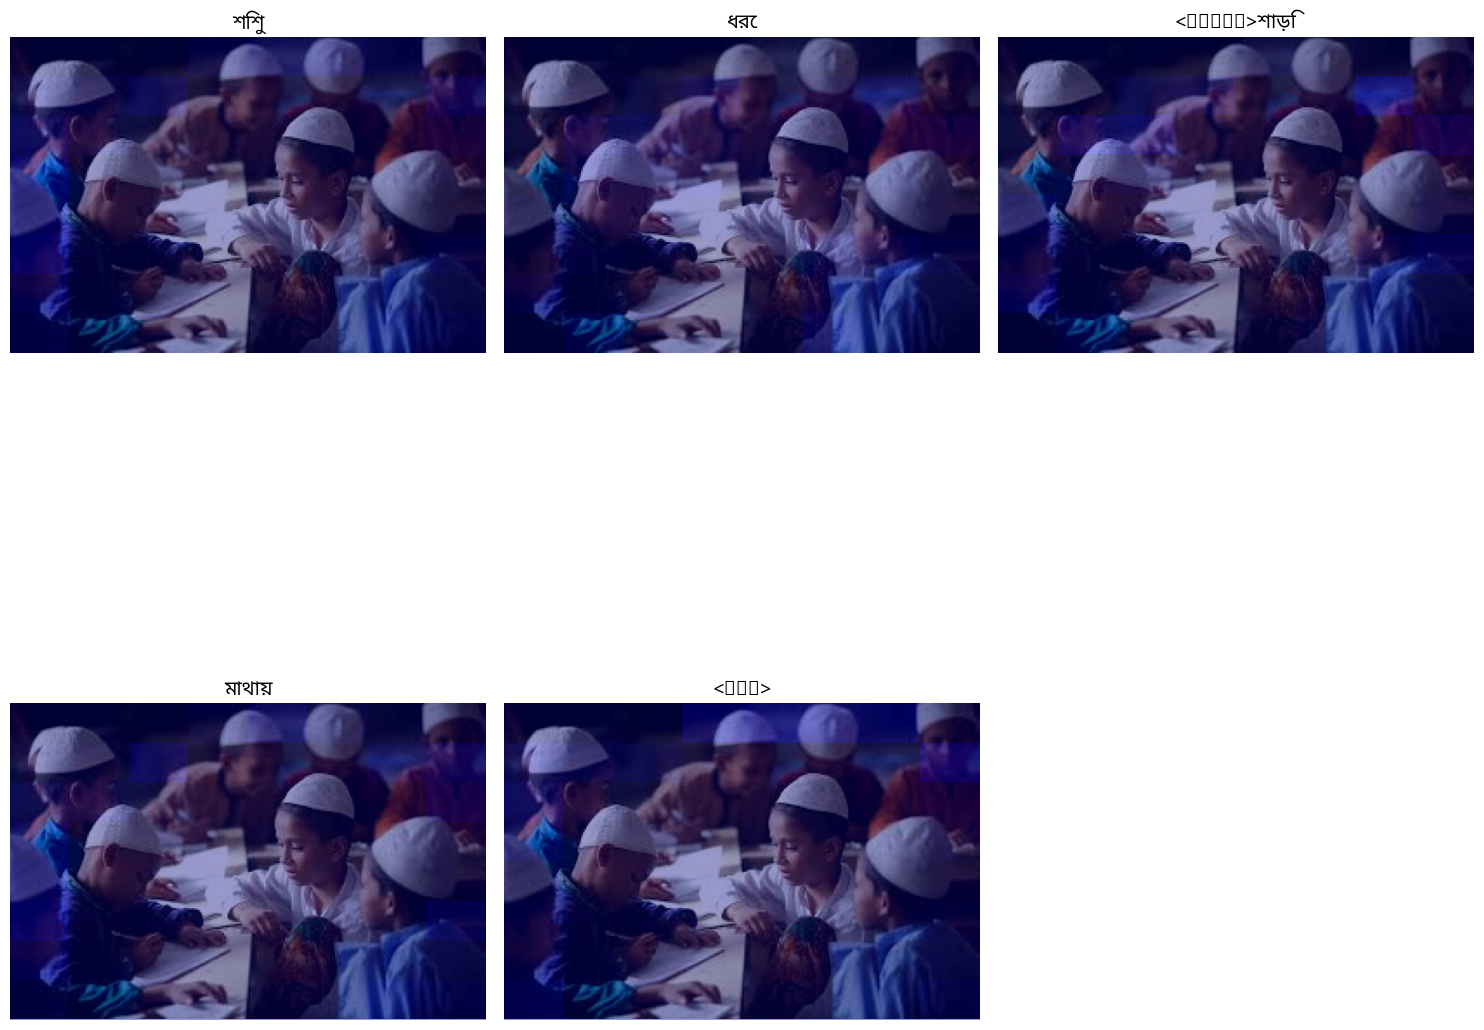


Image: /data/rxxch9vw59-2/images/2253.png
✅ GT: <start> <start>টিশার্ট পরা একটা ছোট ছেলে হাতে কিছু নিয়ে তাকিয়ে আছে। <end>
🤖 Pred: হয়ে মানুষ একজন <end>


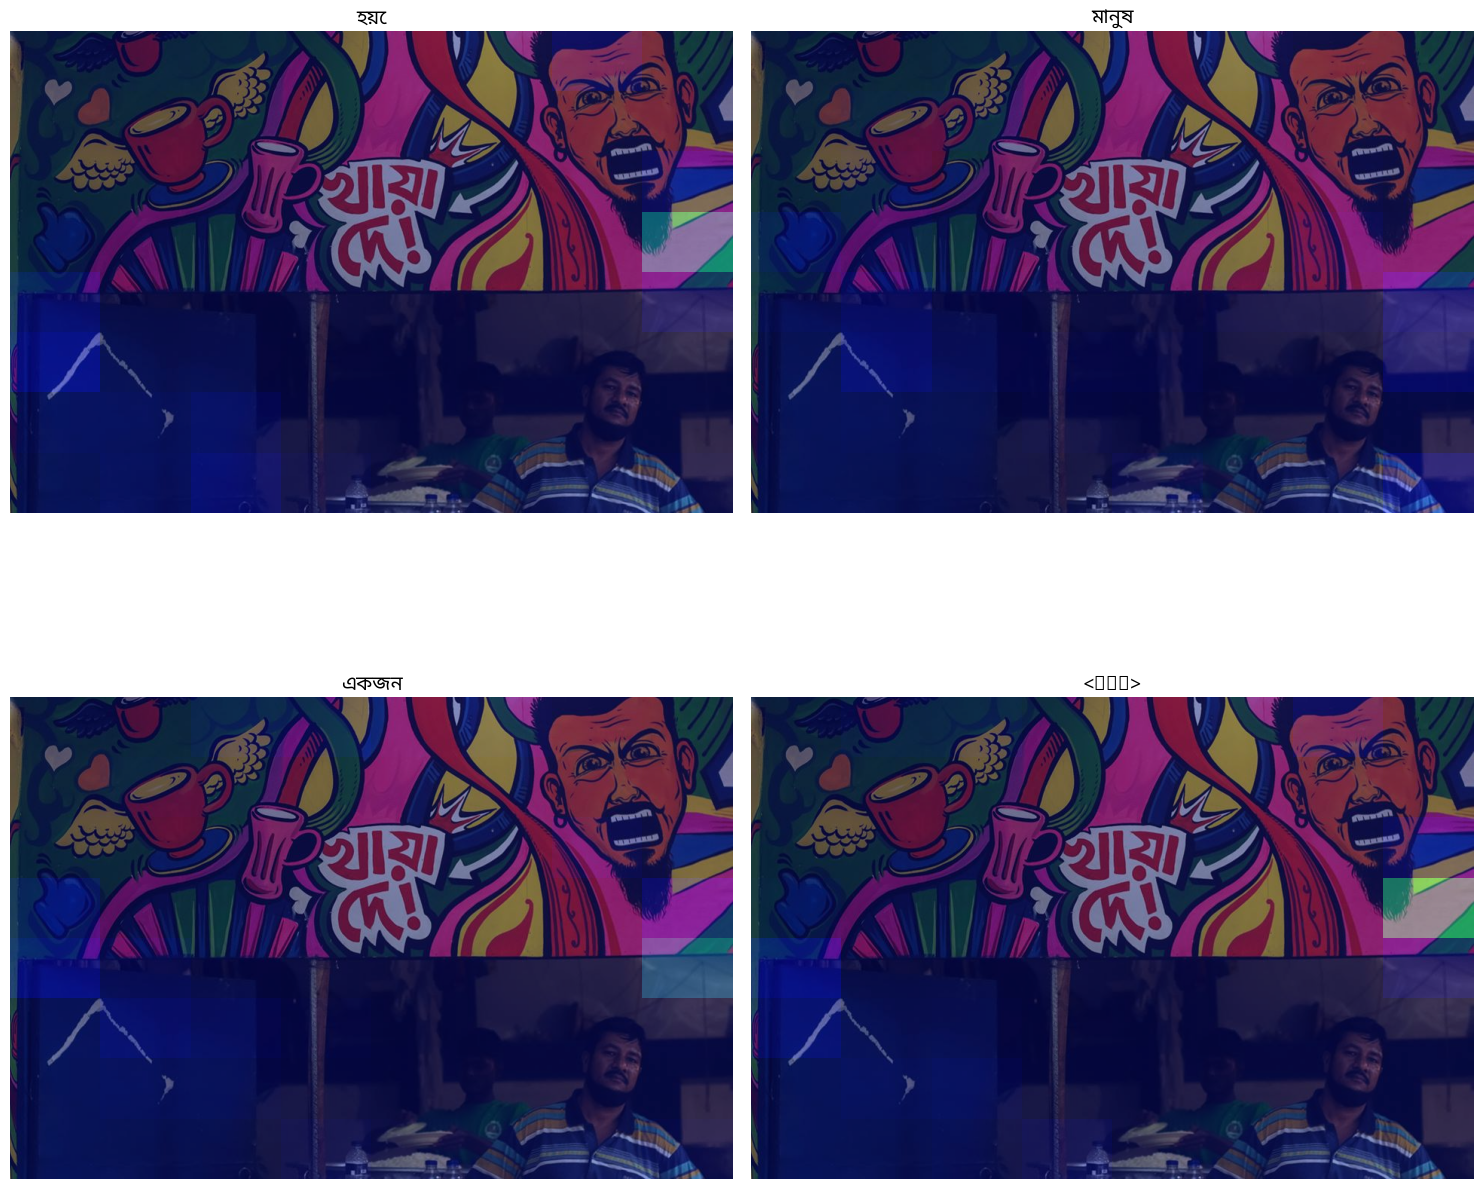


Image: /data/rxxch9vw59-2/images/1203.png
✅ GT: <start> <start>একজন পুরুষ অনেকগুলো নারী ও শিশু বসে আছে। <end>
🤖 Pred: নারীকে লোক ও বাজাচ্ছে। কেটলি <start>ঘরের চলে <end>

🎯 Mode 3: First 3 Validation Images

Image: /data/rxxch9vw59-2/images/1470.png
✅ GT: <start> <start>একজন নারী ও একটি শিশু আছে। <end>
🤖 Pred: <start> হাতে লাল তাদের <start>একটি ছেলে করছে। <unk> <start>দুইজন শারি শাড়ি একটা ঢেকে <end>

Image: /data/rxxch9vw59-2/images/1470.png
✅ GT: <start> <start>একজন নারী ও একটি শিশু আছে। <end>
🤖 Pred: <start> জড়িয়ে রাস্তায় শারি লাঙ্গাল <start>একটি আছে। বালিকা <unk> হাত <unk> <end>

Image: /data/rxxch9vw59-2/images/1725.png
✅ GT: <start> <start>সামনে একজন বয়স্ক নারী বসে আছে। পিছনে একজন নারী একটি শিশু কোলে নিয়ে আছে। <end>
🤖 Pred: শিশু ধরে একজন <end>

📊 Generating Final Report...

✅ Report saved: /results/generated_captions_report.html
📊 BLEU summary saved: /results/bleu_summary.txt

🎉 Inference Complete!
📁 Check results in: /results/
🖼️ Attention plots in: /results/generated_images
📝 HT

In [56]:
print("🚀 Starting Image Caption Inference Pipeline")
print("=" * 50)

print("\n📋 Available Inference Modes:")
print("1. Single random validation image")
print("2. Batch of random validation images")  
print("3. First N validation images")
# print("4. All validation images")

# Mode 1: Single random image
print("\n🎯 Mode 1: Single Random Image")
run_random_single()

# Mode 2: Random batch
print("\n🎯 Mode 2: Random Batch (5 images)")
run_random_batch(num_images=5)

# Mode 3: First N images
print("\n🎯 Mode 3: First 3 Validation Images")
run_first_n(num_images=3)

# Mode 4: All validation images (commented out to avoid long runtime)
# print("\n🎯 Mode 4: All Validation Images")
# run_all(save_output=True)

# ----------------------------
# Generate final report
# ----------------------------
print("\n📊 Generating Final Report...")
finalize_report()

print("\n🎉 Inference Complete!")
print(f"📁 Check results in: {output_dir}")
print(f"🖼️ Attention plots in: {generated_images_dir}")
print(f"📝 HTML report at: {html_report_path}")

# --- Exporting to TFLite for On-Device Flutter Inference ---
This section exports the trained image captioning model (Feature Extractor + Encoder & Decoder loop) to TFLite format.

In [57]:
# Create a wrapped Module that handles CNN Encoder + RNN Decoder step
class TFLiteDecoderWrapper(tf.Module):
    def __init__(self, encoder, decoder):
        super(TFLiteDecoderWrapper, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    @tf.function(input_signature=[
        tf.TensorSpec(shape=[1, 1], dtype=tf.int32, name="dec_input"),
        tf.TensorSpec(shape=[1, 64, 2048], dtype=tf.float32, name="image_features"),
        tf.TensorSpec(shape=[1, 512], dtype=tf.float32, name="hidden")
    ])
    def __call__(self, dec_input, image_features, hidden):
        encoded_features = self.encoder(image_features)
        predictions, next_hidden, attention_weights = self.decoder(dec_input, encoded_features, hidden)
        return {
            "predictions": predictions,
            "next_hidden": next_hidden,
            "attention_weights": attention_weights
        }

class FeatureExtractorWrapper(tf.Module):
    def __init__(self, feature_model):
        super(FeatureExtractorWrapper, self).__init__()
        self.feature_model = feature_model

    @tf.function(input_signature=[
        tf.TensorSpec(shape=[1, 299, 299, 3], dtype=tf.float32, name="input_image")
    ])
    def __call__(self, input_image):
        return self.feature_model(input_image)

# TFLite model output paths
tflite_feature_extractor_path = os.path.join(output_dir, "feature_extractor.tflite")
tflite_decoder_path = os.path.join(output_dir, "decoder.tflite")
vocab_json_path = os.path.join(output_dir, "vocab.json")

print("⏳ Converting InceptionV3 feature extractor to TFLite...")
# Convert Feature Extractor
wrapper_fe = FeatureExtractorWrapper(image_features_extract_model)
fe_converter = tf.lite.TFLiteConverter.from_concrete_functions([
    wrapper_fe.__call__.get_concrete_function()
], wrapper_fe)
fe_tflite = fe_converter.convert()
with open(tflite_feature_extractor_path, 'wb') as f:
    f.write(fe_tflite)
print(f"✅ Feature extractor saved to {tflite_feature_extractor_path}")

print("⏳ Converting Decoder (with CNN Encoder step) to TFLite...")
# Convert Decoder Wrapper
wrapper = TFLiteDecoderWrapper(encoder, decoder)
dec_converter = tf.lite.TFLiteConverter.from_concrete_functions([
    wrapper.__call__.get_concrete_function()
], wrapper)
dec_converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]
dec_tflite = dec_converter.convert()
with open(tflite_decoder_path, 'wb') as f:
    f.write(dec_tflite)
print(f"✅ Decoder saved to {tflite_decoder_path}")

print("⏳ Exporting vocabulary mapping to JSON...")
# Save vocab
vocab_dict = tokenizer.word_index
with open(vocab_json_path, 'w', encoding='utf-8') as f:
    json.dump(vocab_dict, f, ensure_ascii=False, indent=4)
print(f"✅ Vocabulary saved to {vocab_json_path}")


⏳ Converting InceptionV3 feature extractor to TFLite...


2026-05-27 12:25:36.305955: W tensorflow/python/util/util.cc:368] Sets are not currently considered sequences, but this may change in the future, so consider avoiding using them.


INFO:tensorflow:Assets written to: /tmp/tmpyu6ow783/assets


2026-05-27 12:26:08.410540: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:357] Ignored output_format.
2026-05-27 12:26:08.410581: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:360] Ignored drop_control_dependency.
2026-05-27 12:26:08.411500: I tensorflow/cc/saved_model/reader.cc:43] Reading SavedModel from: /tmp/tmpyu6ow783
2026-05-27 12:26:08.451399: I tensorflow/cc/saved_model/reader.cc:78] Reading meta graph with tags { serve }
2026-05-27 12:26:08.451439: I tensorflow/cc/saved_model/reader.cc:119] Reading SavedModel debug info (if present) from: /tmp/tmpyu6ow783
2026-05-27 12:26:08.608915: I tensorflow/cc/saved_model/loader.cc:228] Restoring SavedModel bundle.
2026-05-27 12:26:09.328243: I tensorflow/cc/saved_model/loader.cc:212] Running initialization op on SavedModel bundle at path: /tmp/tmpyu6ow783
2026-05-27 12:26:09.705003: I tensorflow/cc/saved_model/loader.cc:301] SavedModel load for tags { serve }; Status: success: OK. Took 1293506

✅ Feature extractor saved to /results/feature_extractor.tflite
⏳ Converting Decoder (with CNN Encoder step) to TFLite...


INFO:tensorflow:Assets written to: /tmp/tmpliic4gg6/assets


INFO:tensorflow:Assets written to: /tmp/tmpliic4gg6/assets
2026-05-27 12:26:19.465383: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:357] Ignored output_format.
2026-05-27 12:26:19.465443: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:360] Ignored drop_control_dependency.
2026-05-27 12:26:19.465719: I tensorflow/cc/saved_model/reader.cc:43] Reading SavedModel from: /tmp/tmpliic4gg6
2026-05-27 12:26:19.476411: I tensorflow/cc/saved_model/reader.cc:78] Reading meta graph with tags { serve }
2026-05-27 12:26:19.476442: I tensorflow/cc/saved_model/reader.cc:119] Reading SavedModel debug info (if present) from: /tmp/tmpliic4gg6
2026-05-27 12:26:19.522569: I tensorflow/cc/saved_model/loader.cc:228] Restoring SavedModel bundle.
2026-05-27 12:26:19.653620: I tensorflow/cc/saved_model/loader.cc:212] Running initialization op on SavedModel bundle at path: /tmp/tmpliic4gg6
2026-05-27 12:26:19.727193: I tensorflow/cc/saved_model/loader.cc:301] SavedModel

✅ Decoder saved to /results/decoder.tflite
⏳ Exporting vocabulary mapping to JSON...
✅ Vocabulary saved to /results/vocab.json


# --- TFLite Model Verification ---
Verify converted TFLite models using Interpreter.


In [58]:
import tensorflow as tf
import os

results_dir = "/results"
fe_path = os.path.join(results_dir, "feature_extractor.tflite")
dec_path = os.path.join(results_dir, "decoder.tflite")

print("--- Verifying Feature Extractor ---")
fe_interpreter = tf.lite.Interpreter(model_path=fe_path)
fe_interpreter.allocate_tensors()
fe_inputs = fe_interpreter.get_input_details()
fe_outputs = fe_interpreter.get_output_details()

print(f"Feature Extractor Input: {fe_inputs[0]['name']} - Shape: {fe_inputs[0]['shape']} - Dtype: {fe_inputs[0]['dtype']}")
print(f"Feature Extractor Output: {fe_outputs[0]['name']} - Shape: {fe_outputs[0]['shape']} - Dtype: {fe_outputs[0]['dtype']}")

print("\n--- Verifying Decoder ---")
dec_interpreter = tf.lite.Interpreter(model_path=dec_path)
dec_interpreter.allocate_tensors()
dec_inputs = dec_interpreter.get_input_details()
dec_outputs = dec_interpreter.get_output_details()

print("Decoder Inputs:")
for detail in dec_inputs:
    print(f"  {detail['name']}: {detail['shape']} - Dtype: {detail['dtype']}")

print("Decoder Outputs:")
for detail in dec_outputs:
    print(f"  {detail['name']}: {detail['shape']} - Dtype: {detail['dtype']}")

print("\nAll models verified successfully!")


--- Verifying Feature Extractor ---
Feature Extractor Input: serving_default_input_image:0 - Shape: [  1 299 299   3] - Dtype: <class 'numpy.float32'>
Feature Extractor Output: StatefulPartitionedCall:0 - Shape: [   1    8    8 2048] - Dtype: <class 'numpy.float32'>

--- Verifying Decoder ---
Decoder Inputs:
  serving_default_image_features:0: [   1   64 2048] - Dtype: <class 'numpy.float32'>
  serving_default_hidden:0: [  1 512] - Dtype: <class 'numpy.float32'>
  serving_default_dec_input:0: [1 1] - Dtype: <class 'numpy.int32'>
Decoder Outputs:
  StatefulPartitionedCall:0: [ 1 64  1] - Dtype: <class 'numpy.float32'>
  StatefulPartitionedCall:2: [    1 10001] - Dtype: <class 'numpy.float32'>
  StatefulPartitionedCall:1: [  1 512] - Dtype: <class 'numpy.float32'>

All models verified successfully!


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
